Phân lớp và phân cụm khác nhau thế nào


1.1 Bài toán Phân cụm (Clustering) là gì?
    Định nghĩa: Phân cụm là kỹ thuật học không giám sát (Unsupervised Learning).

    Mục tiêu: Phân chia tập dữ liệu thành các nhóm (cụm).

    Nguyên tắc:
        · Các điểm trong cùng một cụm: Tính chất tương đồng cao.

        · Các điểm thuộc cụm khác nhau: Tính chất khác biệt lớn.

        Đặc điểm chính: Dữ liệu đầu vào không có nhãn (Unlabeled data). Thuật toán tự tìm kiếm cấu trúc ẩn.

1.2 Ứng dụng thực tế

    Marketing Phân khúc khách hàng để tối ưu hóa chiến dịch quảng cáo.

    Xử lý tin tức Nhóm các tài liệu hoặc bài báo theo chủ đề tự động.

    Xử lý ảnh Nén ảnh thông qua việc giảm số lượng màu sắc.

    Sinh học Phân tích gen, phân nhóm sinh vật dựa trên đặc điểm.

2.1 Thuật toán K-Means: Ý tưởng cốt lõi

    Mục tiêu: Chia n điểm dữ liệu thành K cụm rời rạc.
    Đại diện: Mỗi cụm được đại diện bởi một Tâm cụm (Centroid).

        Gán điểm Đưa điểm về cụm có tâm gần nhất

        Lặp lại cho đến khi hội tụ

        Cập nhật tâm Dời tâm về vị trí trung bình của cụm

2.2. Quy trình 4 bước của thuật toán

    Bước 1: Khởi tạo Chọn ngẫu nhiên K tâm c tâm cụm từ tập dữ liệu ban đầu.

    Bước 2: Gán cụm Tính khoảng cách từ mỗi điểm đến các tâm. Gán điểm vào cụm có tâm gần nhất.

    Bước 3: Cập nhật tâm Tính lại vị trí tâm mới bằng trung bình (mean) tọa độ các điểm trong cụm.

    Bước 4: Lặp lại Bước 2 & 3 cho đến khi tâm không đổi hoặc đạt số vòng lặp tối đa.

3.1 Cơ sở Toán học: Khoảng cách Euclidean

    Để xác định độ "gần" giữa điểm dữ liệu x và tâm cụm μ. 
    
        Công thức tổng quát:
            d(x,μ) = √Σ(xi-μi)^2

        Trong không gian 2 chiều (2D):
            d=√(x1-μ1)^2 +(x2-μ2)^2

    Cập nhật Tâm cụm:
        Tâm cụm mới là trọng tâm (center of gravity) của các điểm thuộc cụm đó.

        Công thức:

            μk = 1/|C(k)| * Σx

            Giải thích ký hiệu:
            · Hk: Tọa độ mới của tâm cụm k.
            · |Ck|: Số lượng điểm dữ liệu trong cụm k.
            · Σx: Tổng vectơr các điểm thuộc cụm.

3.2 Hàm mục tiêu (Objective Function)
    · Khái niệm: WCSS (Within-Cluster Sum of Squares).
        J = Σ(k)Σ(x∈Ck)||x - μk||^2

    · Mục tiêu: Tìm K tâm cụm sao cho J đạt giá trị nhỏ nhất.

4.1 Chọn số cụm K tối ưu: Phương pháp Elbow

    · Quy trình: Chạy K-Means với K=1, 2, 3 ... và vẽ đồ thị WCSS.

    · Quy tắc: Chọn K tại điểm “khuỷu tay" (Elbow) - nơi độ giảm WCSS bão hòa.



4.2. Phương pháp Silhouette. Đo lường chất lượng phân cụm bằng hệ số Silhouette (-1 đến 1).
    · Gần 1: Phân cụm tốt.
    · Gần 0: Điểm nằm ở biên giới.
    · Âm (< 0): Phân sai cụm.
    · Quy tắc: Chọn K có điểm Silhouette trung bình cao nhất.




In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as snb
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from datetime import datetime
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.cluster import KMeans

In [3]:
mallDf = pd.read_csv('Mall_Customers.csv')
mallDf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
min_income, max_income = mallDf['Annual Income (k$)'].min(), mallDf['Annual Income (k$)'].max()
min_spending, max_spending = mallDf['Spending Score (1-100)'].min(), mallDf['Spending Score (1-100)'].max()
print(f"Annual Income ranges from {min_income}k$ to {max_income}k$")
print(f"Spending Score ranges from {min_spending} to {max_spending}")

Annual Income ranges from 15k$ to 137k$
Spending Score ranges from 1 to 99


In [5]:
features = ['Annual Income (k$)', 'Spending Score (1-100)']
X = mallDf[features]
print(X.shape)

(200, 2)


In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
print(X_scaled[:5])

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


In [8]:
income_scaled_min, income_scaled_max = X_scaled[:,0].min(), X_scaled[:,0].max()
spending_scaled_min, spending_scaled_max = X_scaled[:,1].min(), X_scaled[:,1].max()
print(f'Scaled Income: {income_scaled_min} - {income_scaled_max}')
print(f'Scaled Spending Score: {spending_scaled_min} - {spending_scaled_max}')

Scaled Income: -1.7389991930659485 - 2.9176711658902788
Scaled Spending Score: -1.9100207870073291 - 1.8944921627227165


In [9]:
k = 5
model = KMeans(n_clusters=k, random_state=42)
model.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [ ]:
inertia = model.inertia_ # trung bình khoảng cách từ các điểm đến các tâm.
print(f'Inertia: {inertia}')

Inertia: 65.56840815571681


In [11]:
labels = model.labels_
df_labeled = X.copy()
df_labeled['Cluster'] = labels
df_labeled.head()

,Annual Income (k$),Spending Score (1-100),Cluster
0,15,39,4
1,15,81,2
2,16,6,4
3,16,77,2
4,17,40,4


In [12]:
centroids = model.cluster_centers_
print(centroids)

[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


Text(0.5, 1.0, 'K-Means Clustering of Mall Customers')

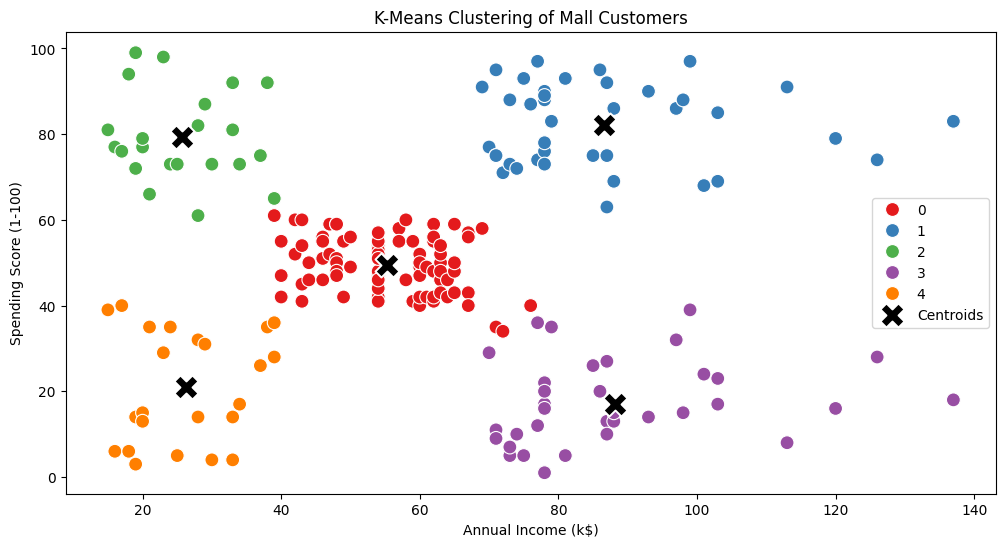

In [13]:
plt.figure(figsize=(12, 6))
snb.scatterplot(data=df_labeled, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', palette='Set1', s=100)
snb.scatterplot(x=centroids[:,0]*scaler.scale_[0] + scaler.mean_[0], 
                y=centroids[:,1]*scaler.scale_[1] + scaler.mean_[1], 
                color='black', s=300, marker='X', label='Centroids')
plt.title('K-Means Clustering of Mall Customers')

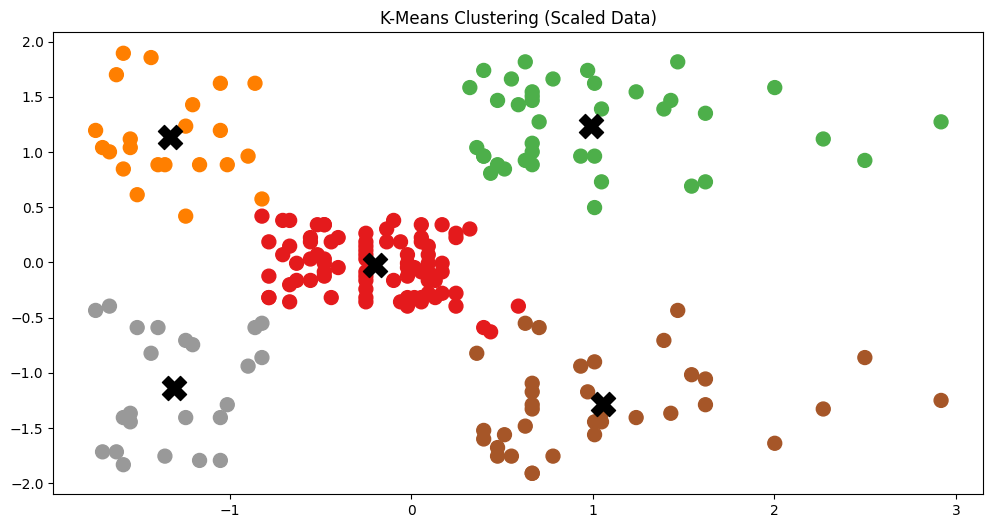

In [14]:
plt.figure(figsize=(12, 6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap='Set1', s=100)
plt.scatter(centroids[:,0], centroids[:,1], color='black', s=300, marker='X', label='Centroids')
plt.title('K-Means Clustering (Scaled Data)')
plt.show()

In [15]:
from sklearn.datasets import load_wine
wineDf = load_wine(as_frame=True).frame
wineDf.info()

wineDf.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


[[ 1.51861254 -0.5622498 ]
 [ 0.24628963 -0.49941338]
 [ 0.19687903  0.02123125]
 [ 1.69154964 -0.34681064]
 [ 0.29570023  0.22769377]]


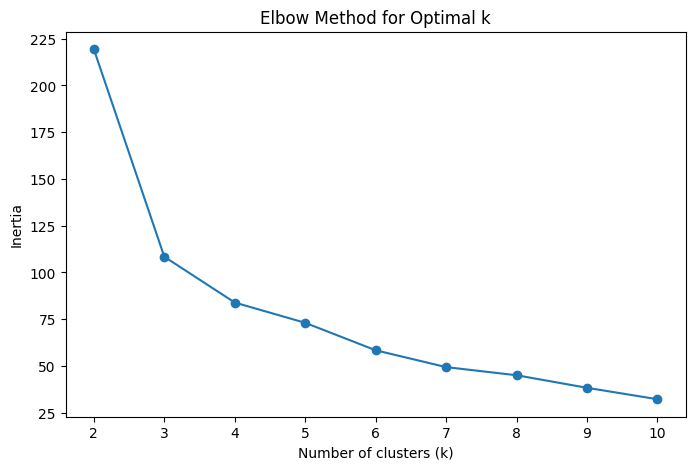

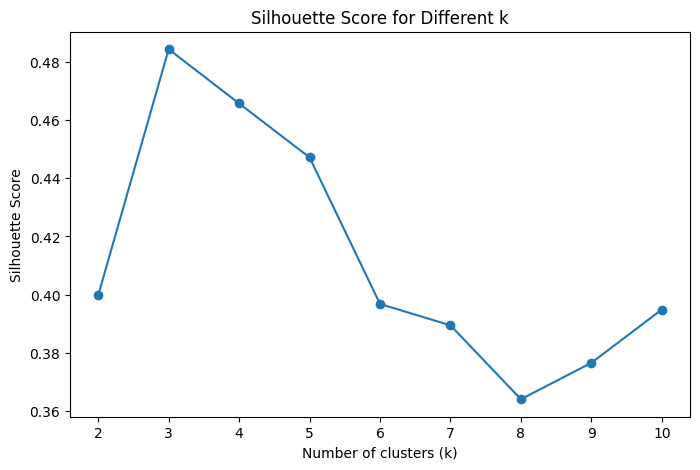

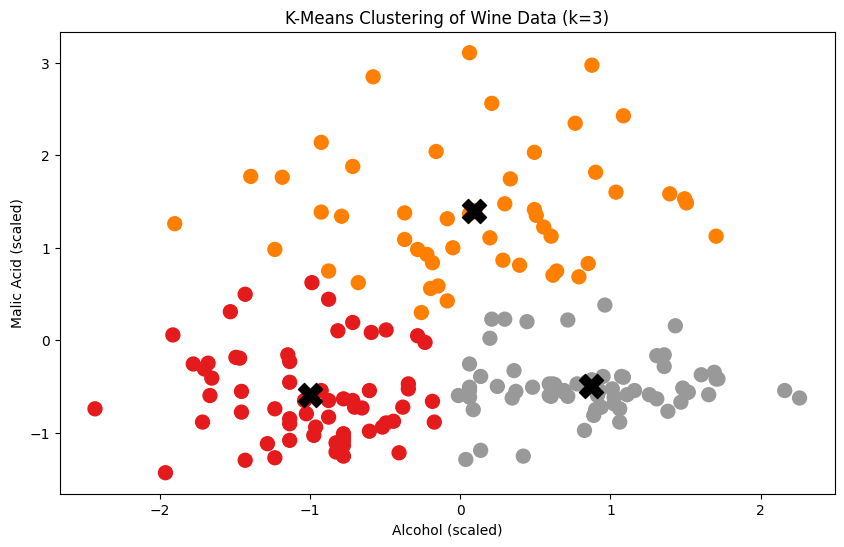

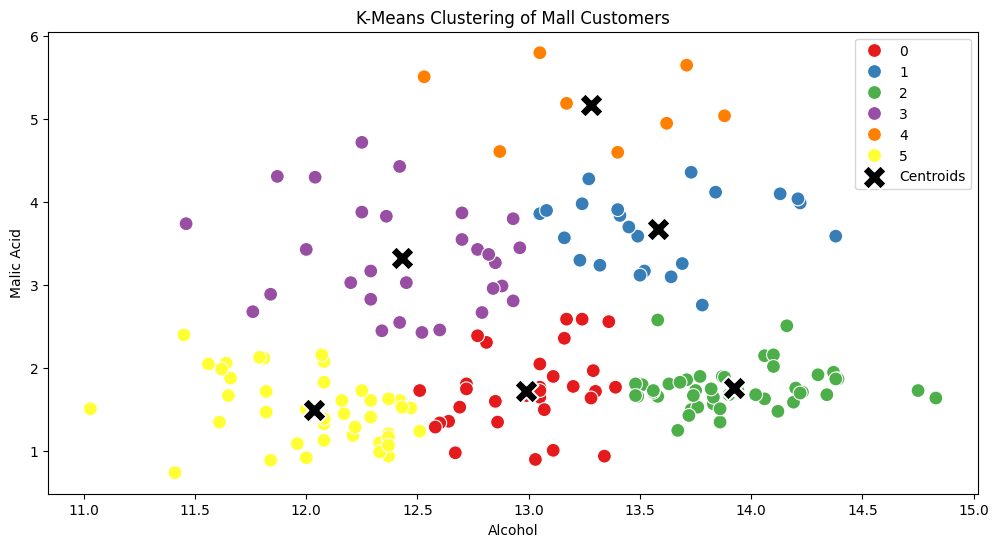

In [16]:
# chọn 2 đặc trưng
features = ['alcohol', 'malic_acid']
X_wine = wineDf[features]

# Chuẩn hóa dữ liệu (StandardScaler)
scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)
print(X_wine_scaled[:5])

# Chạy KMeans với k từ 2 đến n (tùy chọn)
inertia_values = []
k_values = range(2, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_wine_scaled)
    inertia_values.append(kmeans.inertia_)
# Vẽ đồ thị Elbow
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.show()

# Tính silhouette score
from sklearn.metrics import silhouette_score
list_k = range(2, 11)
silhouette_scores = []

for k in list_k:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_wine_scaled)

    sil_avg = silhouette_score(X_wine_scaled, model.labels_)
    silhouette_scores.append(sil_avg)

# Vẽ đồ thị silhouette score
plt.figure(figsize=(8, 5))
plt.plot(list_k, silhouette_scores, marker='o')
plt.title('Silhouette Score for Different k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(list_k)
plt.show()

# Vẽ đồ thị phân cụm với k = 3, dùng pyplot scatter
k_optimal = 3
kmeans_optimal = KMeans(n_clusters=k_optimal, random_state=42)
kmeans_optimal.fit(X_wine_scaled)
labels_optimal = kmeans_optimal.labels_
centroids_optimal = kmeans_optimal.cluster_centers_
plt.figure(figsize=(10, 6))
plt.scatter(X_wine_scaled[:,0], X_wine_scaled[:,1], c=labels_optimal, cmap='Set1', s=100)
plt.scatter(centroids_optimal[:,0], centroids_optimal[:,1], color='black', s=300, marker='X', label='Centroids')
plt.title('K-Means Clustering of Wine Data (k=3)')
plt.xlabel('Alcohol (scaled)')
plt.ylabel('Malic Acid (scaled)')
plt.show()


# Vẽ đồ thị phân cụm với k = 6, dùng scatterplot seaborn
k_optimal = 6
kmeans_optimal = KMeans(n_clusters=k_optimal, random_state=42)
kmeans_optimal.fit(X_wine_scaled)
labels = kmeans_optimal.labels_
centroids_optimal = kmeans_optimal.cluster_centers_
df_labeled = X_wine.copy()
df_labeled['Cluster'] = labels
df_labeled.head()
plt.figure(figsize=(12, 6))
snb.scatterplot(data=df_labeled, x='alcohol', y='malic_acid', hue='Cluster', palette='Set1', s=100)
snb.scatterplot(x=centroids_optimal[:,0]*scaler_wine.scale_[0] + scaler_wine.mean_[0], 
                y=centroids_optimal[:,1]*scaler_wine.scale_[1] + scaler_wine.mean_[1], 
                color='black', s=300, marker='X', label='Centroids')
plt.title('K-Means Clustering of Mall Customers')
plt.xlabel('Alcohol')
plt.ylabel('Malic Acid')
plt.show()